<a href="https://colab.research.google.com/github/Adeline187/Build_and_Deploy-ML/blob/main/EXPT2/SVM_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification using Support Vector Machine (SVM) & Random Forest

This experiment evaluates and compares the performance of Support Vector Machines (SVM) and Random Forest classifiers on the Iris dataset.

## 1. Import Required Libraries
Import numerical manipulation tools (`numpy`, `pandas`), visualization libraries (`seaborn`, `matplotlib`), and essential `scikit-learn` modules.

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## 2. Load and Inspect the Iris Dataset
Load the raw Iris data, create a structured DataFrame for initial inspection, and check for missing values.

In [3]:
iris = load_iris()

X = iris.data
y = iris.target

df = pd.DataFrame(X, columns=iris.feature_names)
df["Target"] = y

print("First Five Records:")
print(df.head())

print("\nDataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

First Five Records:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Target  
0       0  
1       0  
2       0  
3       0  
4       0  

Dataset Shape: (150, 5)

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
Target               0
dtype: int64


## 3. Feature Scaling & Train-Test Split
Standardize the features using `StandardScaler` and partition the dataset into training (70%) and testing (30%) sets.

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.3,
    random_state=42
)

## 4. Part A: Support Vector Machine (SVM)
Train a linear Support Vector Classifier (SVC) on the training set, generate predictions on the test set, and evaluate metrics.

In [5]:
print("==============================")
print("Support Vector Machine (SVM)")
print("==============================")

svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)
svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("\nSVM Accuracy:", svm_accuracy)
print("\nSVM Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("\nSVM Classification Report:\n", classification_report(y_test, y_pred_svm))

Support Vector Machine (SVM)

SVM Accuracy: 0.9777777777777777

SVM Confusion Matrix:
 [[19  0  0]
 [ 0 12  1]
 [ 0  0 13]]

SVM Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      0.92      0.96        13
           2       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45



## 5. Part B: Random Forest Classifier
Instantiate and train a Random Forest ensemble classifier with 100 decision trees and review performance indicators.

In [6]:
print("==============================")
print("Random Forest")
print("==============================")

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("\nRandom Forest Accuracy:", rf_accuracy)
print("\nRandom Forest Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nRandom Forest Classification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest

Random Forest Accuracy: 1.0

Random Forest Confusion Matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

Random Forest Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



## 6. Model Performance Comparison & Visualization
Compare the overall test set accuracies and plot side-by-side heatmaps of the confusion matrices using `seaborn`.

Model Comparison
SVM Accuracy           : 0.9778
Random Forest Accuracy : 1.0000


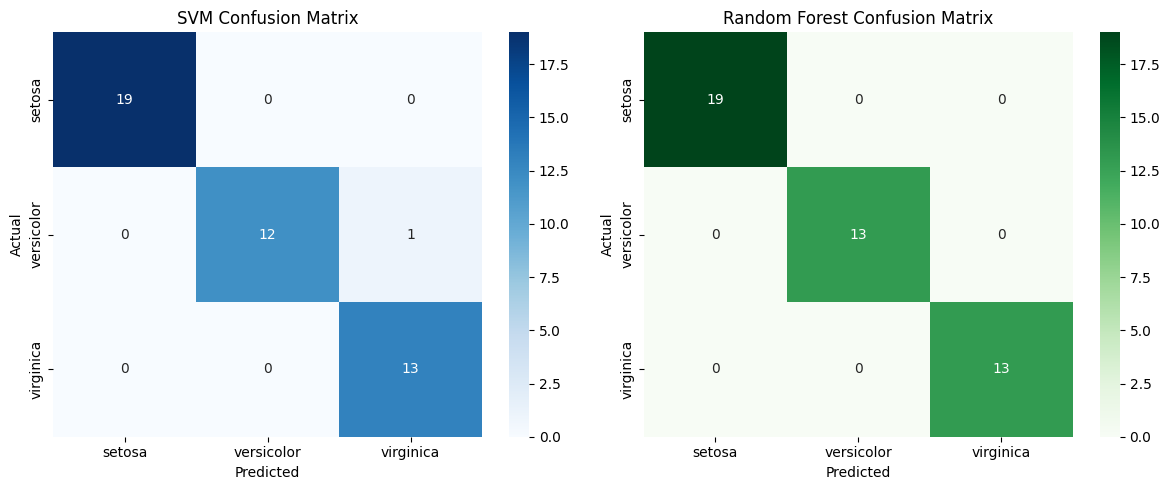

In [7]:
print("==============================")
print("Model Comparison")
print("==============================")
print(f"SVM Accuracy           : {svm_accuracy:.4f}")
print(f"Random Forest Accuracy : {rf_accuracy:.4f}")

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.heatmap(
    confusion_matrix(y_test, y_pred_svm),
    annot=True,
    cmap="Blues",
    fmt="d",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.subplot(1,2,2)
sns.heatmap(
    confusion_matrix(y_test, y_pred_rf),
    annot=True,
    cmap="Greens",
    fmt="d",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()